# python for stock trading


##### this ducument explains how to import stock's data from YAHOO, choose the best market to invest in, calculate you portfolio, and other intersting things.

In [34]:
import yfinance
import mplfinance as mpf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000

sns.set()

# downloading Data From YAHOO!

In [35]:
stocknames = ['AAPL', 'MSFT', 'TSLA', 'GC=F', 'SPY']
startdate = '2025-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [36]:
for stock in stocknames:
    df = yfinance.download(stock, start=startdate, end=enddate, interval=interval, auto_adjust=False, actions=False)
    df.reset_index(inplace=True)
    df.to_csv('{}.csv'.format(stock), index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [37]:
def appnding(cols = [], startdate='', enddate=''):
    global df
    dates = pd.date_range(start=startdate, end=enddate)
    df = pd.DataFrame(index=dates)
    
    for stock in stocknames:
        df_symbols = pd.read_csv('{}.csv'.format(stock), index_col='Date', parse_dates=True, usecols=cols, na_values=['NAN'])
        df_symbols = df_symbols.rename(columns={'Adj Close': stock})
        df = df.join(df_symbols)
    
    df = df.dropna()
    return df

In [38]:
appnding(['Date', 'Adj Close'], startdate, enddate)
df.index.names = ['Date']
df = df.rename(columns={'GC=F':'gold', 'AAPL' : 'aapl', 'MSFT' : 'msft', 'TSLA' : 'tsla', 'SPY':'spy'})
df.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,242.525146484375,414.568603515625,379.2799987792969,2658.89990234375,576.2803344726562
2025-01-03,242.03781127929688,419.29290771484375,410.44000244140625,2645.0,583.48583984375
2025-01-06,243.6688995361328,423.7497863769531,411.04998779296875,2638.39990234375,586.8470458984375
2025-01-07,240.89407348632812,418.3222351074219,394.3599853515625,2656.699951171875,580.2133178710938
2025-01-08,241.3814239501953,420.49127197265625,394.94000244140625,2664.5,581.0609741210938


## GLOBAL STATISTICS

In [39]:
df = df.astype(float)
df_desc = df.describe().T
df_desc = df_desc[['count', 'mean', 'std', '50%', 'max']]
df_desc

,count,mean,std,50%,max
aapl,338.00,239.73,27.18,242.28,293.32
msft,338.00,449.31,51.31,454.10,539.83
tsla,338.00,368.60,64.79,378.98,489.88
gold,338.00,"3,805.75",739.72,"3,625.05","5,318.40"
spy,338.00,632.69,52.47,642.58,737.62


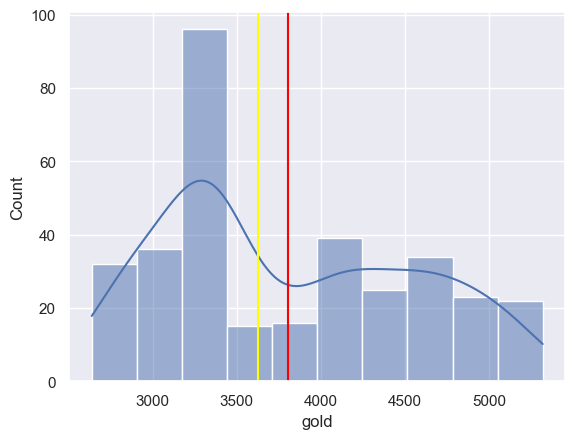

In [40]:
sns.histplot(data=df, x='gold', kde=True)
plt.axvline(df.gold.mean(), color="red")
plt.axvline(df.gold.median(), color="yellow")

In [41]:
px.line(data_frame=df, title='tickers adj. close price')

### normalizing

In [42]:
norm = df / df.iloc[0,:]
fig = px.line(norm)
fig.update_layout(title='stack movement observation by normalizing adj close prices , (daily cumulative return)',
                   xaxis_title='Date', 
                   yaxis_title='Normalized price')
fig.show()

<Axes: xlabel='tsla', ylabel='Count'>

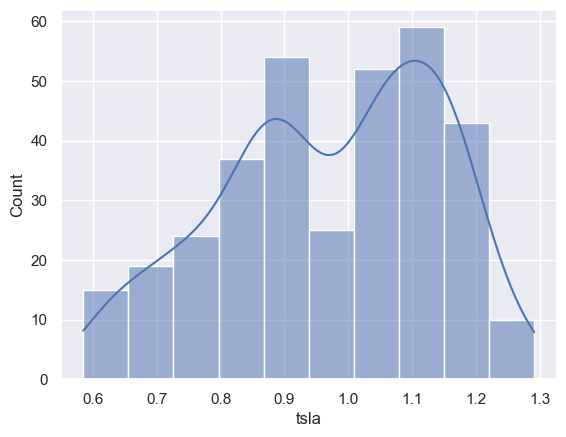

In [43]:
sns.histplot(data=norm, x=norm['tsla'], kde=True)

### Rolling Statistics

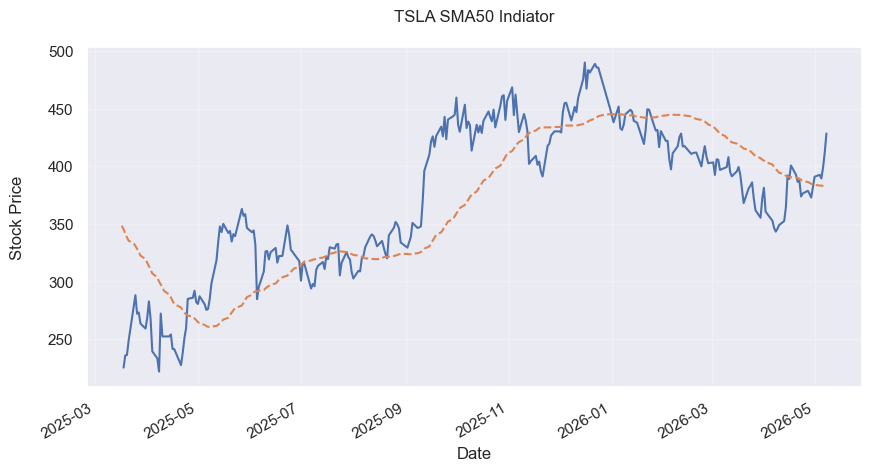

In [44]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(10,5))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('TSLA SMA50 Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
plt.grid(alpha=0.25)

### Bollinger Bands

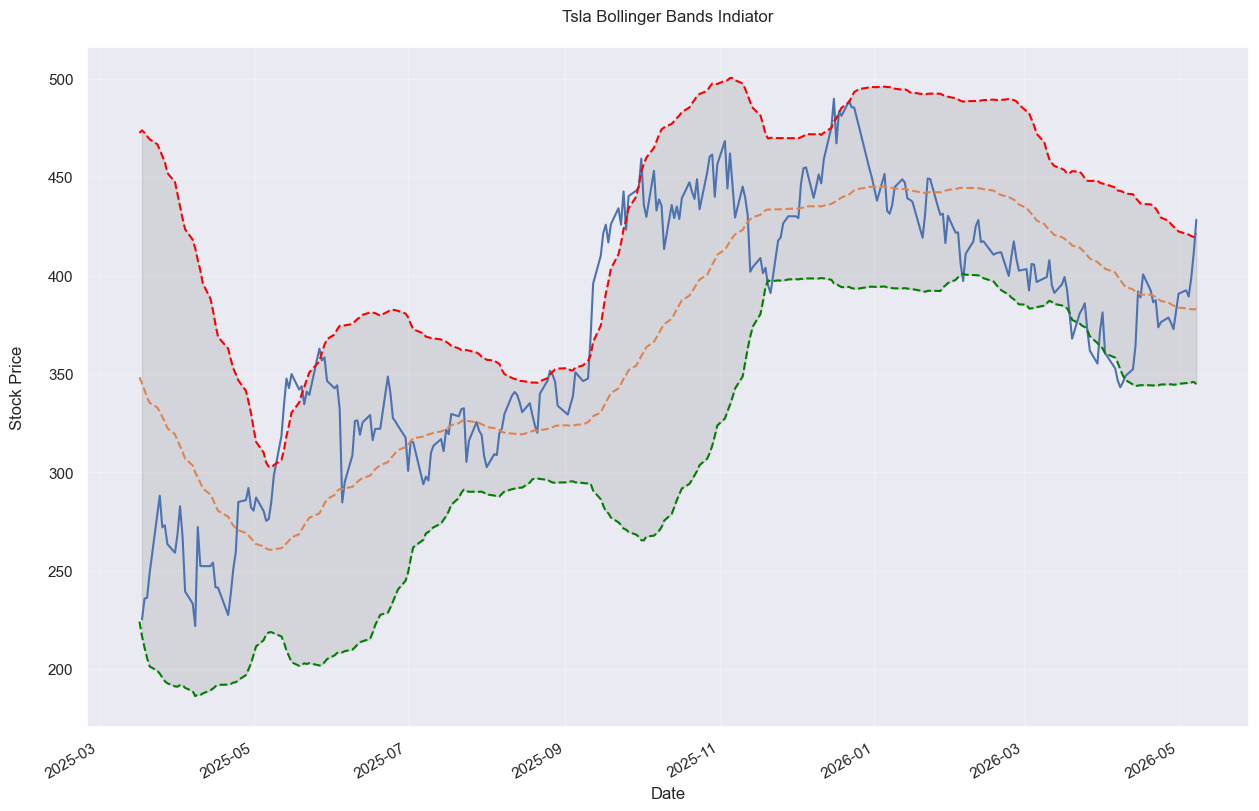

In [45]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(15,10))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('Tsla Bollinger Bands Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
upper_band = rollingmean + rollingstd
lower_band = rollingmean - rollingstd
upper_band.plot(ax=ax, linestyle='--', label='Upper Band (+2 STD)', color='red')
lower_band.plot(ax=ax, linestyle='--', label='Lower Band (-2 STD)', color='green')
ax.fill_between(df.index[50:], upper_band.iloc[50:], lower_band.iloc[50:], alpha=0.2, color='gray')
plt.grid(alpha=0.25)

### - Matrics

-daily Returns
-commuulative Returns
-sharpe Ratio

In [46]:
daily_returns = df.pct_change()
daily_returns.iloc[0,:] = 0
daily_returns.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,0.00,0.00,0.00,0.00,0.00
2025-01-03,-0.00,0.01,0.08,-0.01,0.01
2025-01-06,0.01,0.01,0.00,-0.00,0.01
2025-01-07,-0.01,-0.01,-0.04,0.01,-0.01
2025-01-08,0.00,0.01,0.00,0.00,0.00


In [47]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,338.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,338.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,338.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,338.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,338.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


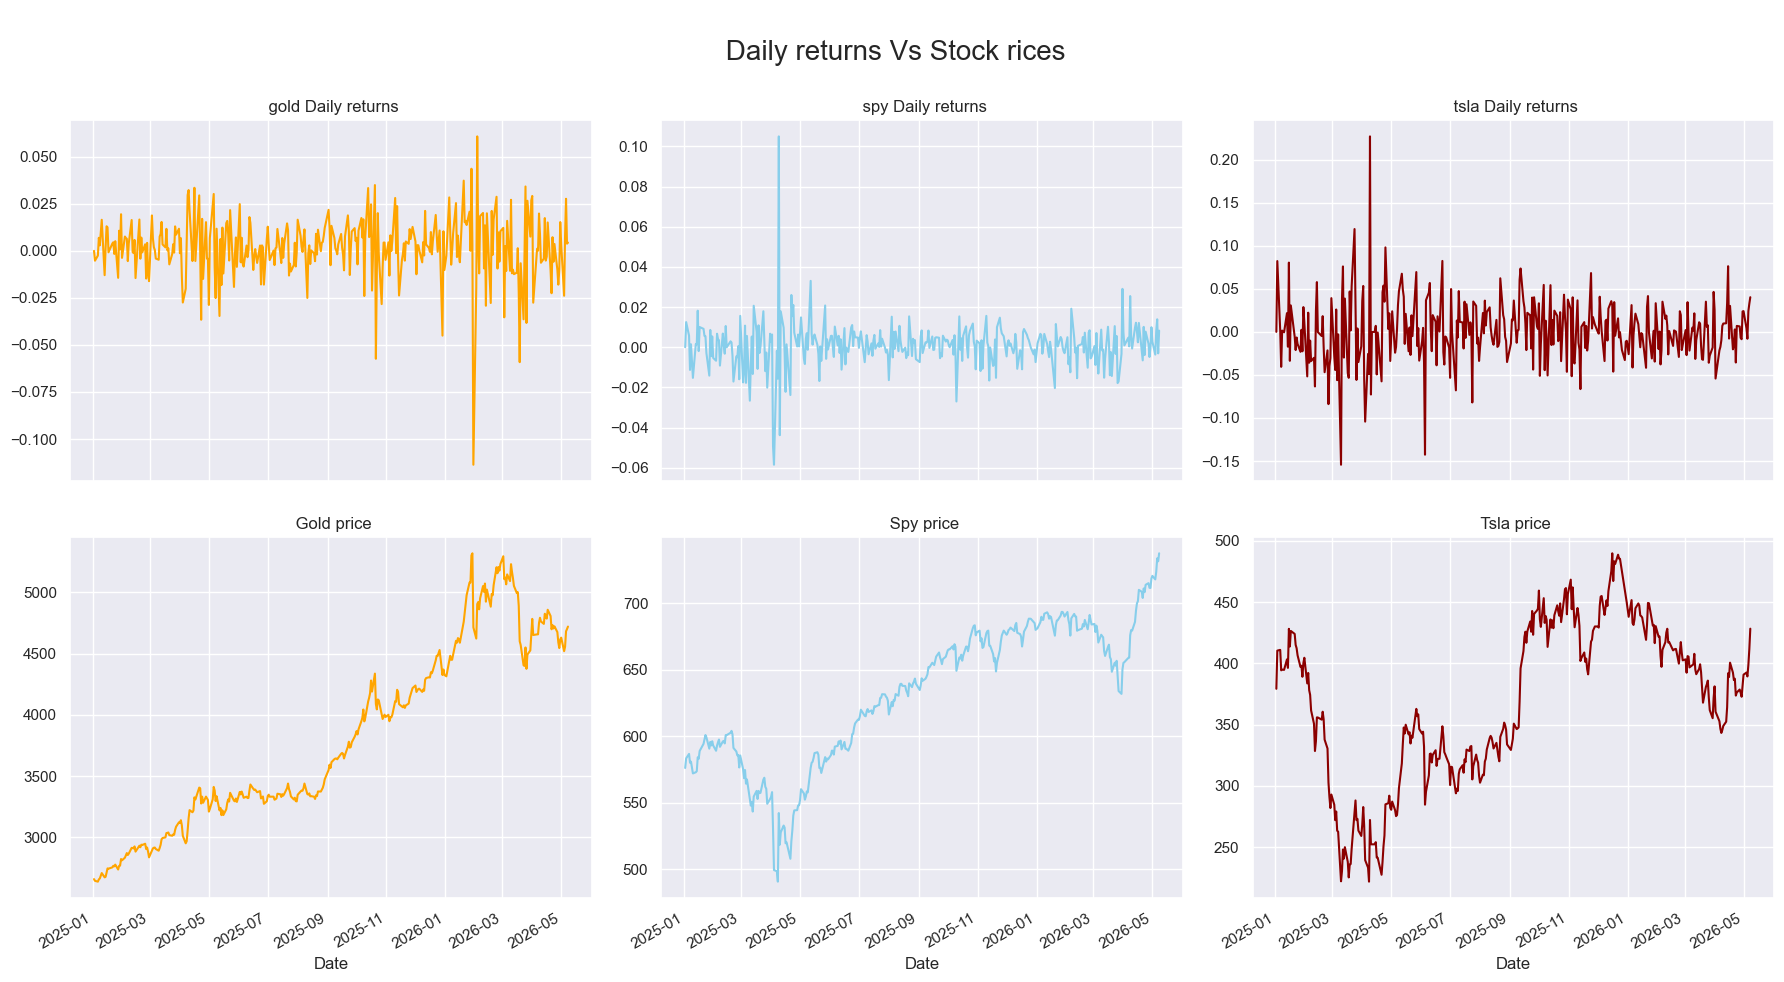

In [48]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

daily_returns.gold.plot(ax=ax[0][0], color='orange')
ax[0][0].set_title('\n gold Daily returns')

daily_returns.spy.plot(ax=ax[0][1], color='skyblue')
ax[0][1].set_title('\n spy Daily returns')

daily_returns.tsla.plot(ax=ax[0][2], color='darkred')
ax[0][2].set_title('\n tsla Daily returns')

df.gold.plot(kind='line', ax=ax[1][0], color='orange')
ax[1][0].set_title('\n Gold price')

df.spy.plot(kind='line', ax=ax[1][1], color='skyblue')
ax[1][1].set_title('\n Spy price')

df.tsla.plot(kind='line', ax=ax[1][2], color='darkred')
ax[1][2].set_title('\n Tsla price')
fig.suptitle('\n Daily returns Vs Stock rices', fontsize=20)
plt.tight_layout()

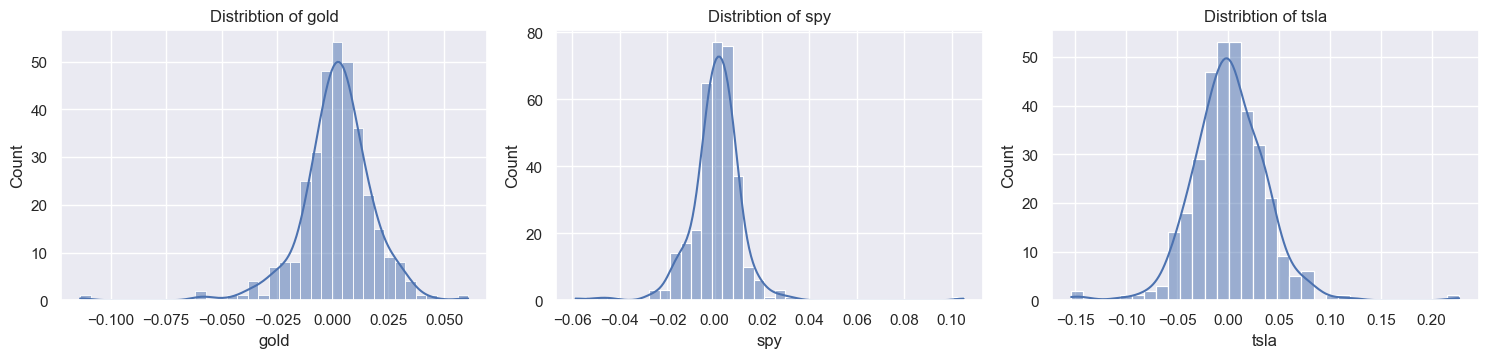

In [49]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['gold', 'spy', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True)
    plt.title("Distribtion of " + i)
    plt.tight_layout()




### cumulative returns ratio: is the profit/lose ratio of the stock on practicular period 

In [50]:
stocknames = df.columns

for stock in stocknames:
    print("cumulative return of {} is: {} %".format(stock, round(((df.iloc[-1][stock] / df.iloc[0][stock]) - 1) * 100, 2)))

cumulative return of aapl is: 20.94 %
cumulative return of msft is: 0.13 %
cumulative return of tsla is: 12.94 %
cumulative return of gold is: 77.53 %
cumulative return of spy is: 28.0 %


In [51]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,338.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,338.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,338.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,338.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,338.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


<Axes: xlabel='Date'>

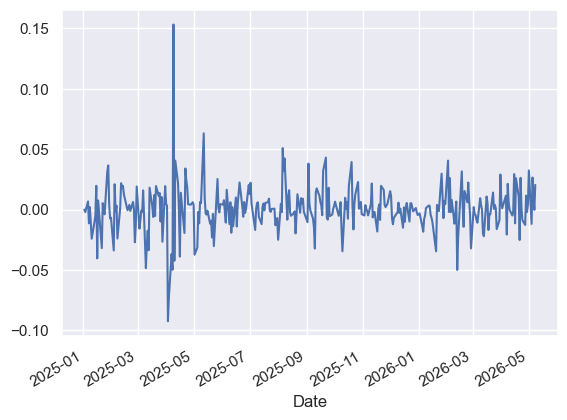

In [52]:
daily_returns.aapl.plot()

In [53]:
((daily_returns.gold[daily_returns.gold >= 0].sum()) + (daily_returns.gold[daily_returns.gold < 0].sum())) * 100

np.float64(61.919304151034616)

#### mean
### STD
### Kurtosis
### (volatiliy)risk/return

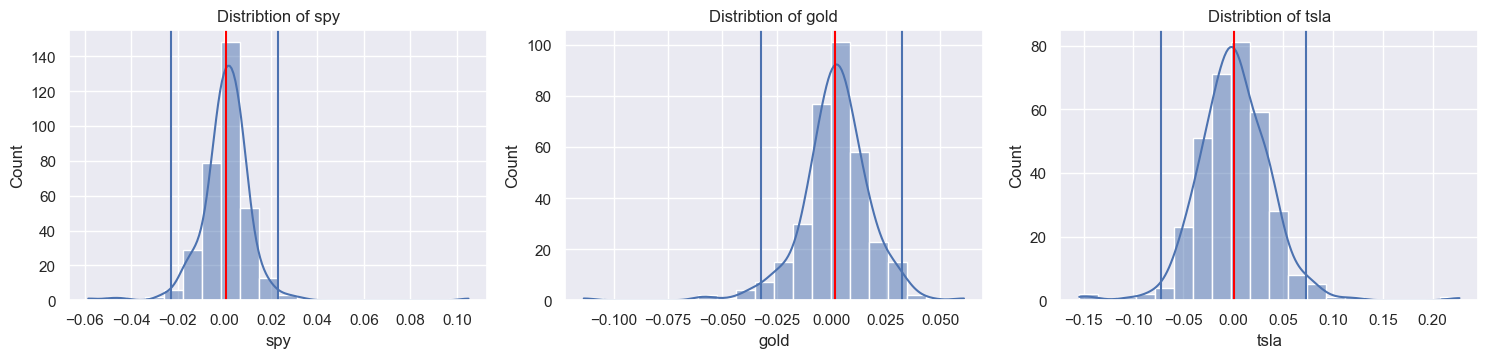

In [54]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['spy', 'gold', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True, bins=20)
    plt.axvline(daily_returns[i].mean(), color="red")
    plt.axvline(daily_returns[i].std() * 2)
    plt.axvline(-daily_returns[i].std() * 2)
    plt.title("Distribtion of " + i)
    plt.tight_layout()


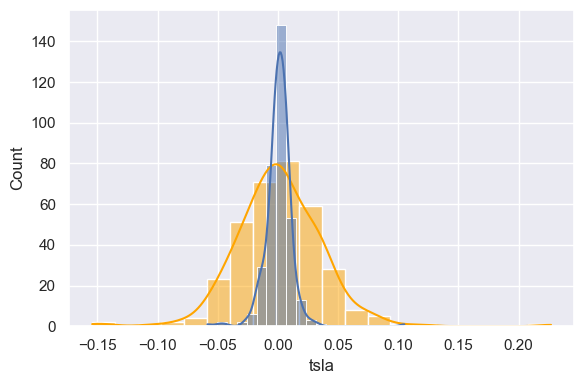

In [55]:
plt.figure(figsize=(6, 4))
sns.histplot(daily_returns.tsla, kde=True, bins=20, color="orange")
sns.histplot(daily_returns.spy, kde=True, bins=20)
plt.tight_layout()

In [56]:
print(f'the mean of Spy dr = {daily_returns.spy.mean() * 100}')
print(f'the std of Spy dr = {daily_returns.spy.std()}')
print(f'the kurtosis of Spy dr = {daily_returns.spy.kurtosis()}')

the mean of Spy dr = 0.07953850296701169
the std of Spy dr = 0.01145992879562824
the kurtosis of Spy dr = 23.029020733319243


In [57]:
print(f'the mean of tsla dr = {daily_returns.tsla.mean() * 100}')
print(f'the std of tsla dr = {daily_returns.tsla.std()}')
print(f'the kurtosis of tsla dr = {daily_returns.tsla.kurtosis()}')

the mean of tsla dr = 0.10150320332685521
the std of tsla dr = 0.03636914789406336
the kurtosis of tsla dr = 5.413818766320807


## linear Regression model

[[1.         0.72085534]
 [0.72085534 1.        ]]


<Axes: >

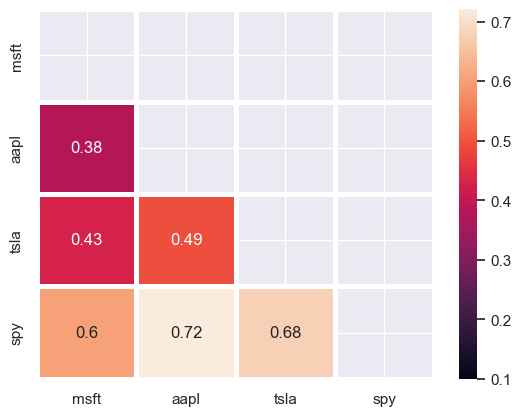

In [58]:
daily_returns = daily_returns[['msft', 'aapl', 'tsla', 'spy']]
print(np.corrcoef(daily_returns.spy, daily_returns.aapl))
mask = np.zeros_like(daily_returns.corr())
mask[np.triu_indices_from(mask)] = True
mask
sns.heatmap(daily_returns.corr(), annot=True, vmin=0.1, mask=mask, linewidths=2.5)

<Axes: xlabel='tsla', ylabel='spy'>

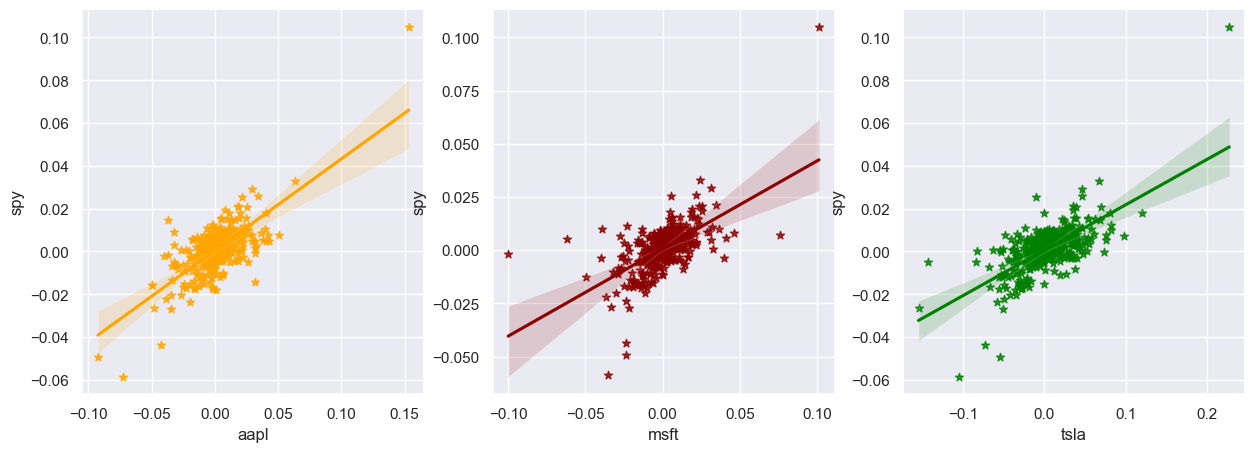

In [81]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.regplot(data=daily_returns, x=daily_returns.aapl, y=daily_returns.spy, scatter=True, marker="*", ax=ax[0], color="orange")
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.spy, scatter=True, marker="*", ax=ax[1], color="darkred")
sns.regplot(data=daily_returns, x=daily_returns.tsla, y=daily_returns.spy, scatter=True, marker="*", ax=ax[2], color="green")

<Axes: xlabel='msft', ylabel='aapl'>

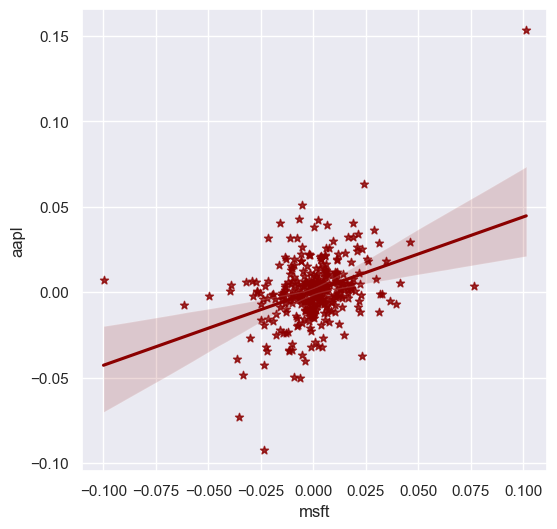

In [69]:
plt.figure(figsize=(6, 6))
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.aapl, scatter=True, marker="*", color="darkred")


In [70]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'aapl']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     363.5
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.92e-55
Time:                        17:35:20   Log-Likelihood:                 1155.3
No. Observations:                 338   AIC:                            -2307.
Df Residuals:                     336   BIC:                            -2299.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005      0.000      1.099      0.272      -0.000       0.001
aapl           0.4279      0.022     19.065      0.000       0.384       0.472
==============================================================================
Omnibus:                       24.030   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               84.158
Skew:                           0.086   Prob(JB):                     5.31e-19
Kurtosis:                       5.439   Cond. No.                         51.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'msft']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     193.2
Date:                Mon, 11 May 2026   Prob (F-statistic):           5.12e-35
Time:                        17:39:57   Log-Likelihood:                 1108.2
No. Observations:                 338   AIC:                            -2212.
Df Residuals:                     336   BIC:                            -2205.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.000      1.479      0.140      -0.000       0.002
msft           0.4119      0.030     13.900      0.000       0.354       0.470
==============================================================================
Omnibus:                       85.435   Durbin-Watson:                   2.227
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1349.260
Skew:                           0.539   Prob(JB):                    1.03e-293
Kurtosis:                      12.728   Cond. No.                         59.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'tsla']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     281.6
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.51e-46
Time:                        18:00:30   Log-Likelihood:                 1134.3
No. Observations:                 338   AIC:                            -2265.
Df Residuals:                     336   BIC:                            -2257.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0006      0.000      1.258      0.209      -0.000       0.001
tsla           0.2128      0.013     16.780      0.000       0.188       0.238
==============================================================================
Omnibus:                       68.524   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              771.945
Skew:                           0.414   Prob(JB):                    2.37e-168
Kurtosis:                      10.357   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [83]:
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.aapl, daily_returns.spy)
print(f"AAPL/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.msft, daily_returns.spy)
print(f"MSFT/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.tsla, daily_returns.spy)
print(f"TSLA/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")

AAPL/SPY
beta slop = 0.4278544263460126
alpha (intercept) = 0.0004759279782391856
R-squared = 0.5196324264972166
pvalue = 1.9221979821655228e-55
MSFT/SPY
beta slop = 0.4119102296338673
alpha (intercept) = 0.000735721517256896
R-squared = 0.36510561809231523
pvalue = 5.115414770931601e-35
TSLA/SPY
beta slop = 0.2127614998776437
alpha (intercept) = 0.0005794252918480455
R-squared = 0.455919848777781
pvalue = 2.5052274764966696e-46
